## 1   Imports & Toy Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
 

In [2]:
# Reproducibility
np.random.seed(42)

In [3]:
# Synthetic data: temperature (°C) vs. ice-cream sales (units/day)
temp = np.linspace(20, 40, 35) # Temperature from 20 to 40 degrees
noise = np.random.normal(0, 3, size=temp.shape)
sale = 2 * temp - 30+noise # Sales with some noise
data = pd.DataFrame({'Temperature': temp, 'IceCreamSales': sale})

data.head()


,Temperature,IceCreamSales
0,20.000000,11.490142
1,20.588235,10.761678
2,21.176471,14.296007
3,21.764706,18.098501
4,22.352941,14.003422


In [13]:
data.shape

(35, 2)

In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Temperature    35 non-null     float64
 1   IceCreamSales  35 non-null     float64
dtypes: float64(2)
memory usage: 692.0 bytes


In [19]:
data.describe()

,Temperature,IceCreamSales
count,35.000000,35.000000
mean,30.000000,29.602072
std,6.027618,11.949254
min,20.000000,10.761678
25%,25.000000,20.456026
50%,30.000000,28.116030
75%,35.000000,38.835445
max,40.000000,52.467635


## 2 Quick EDA

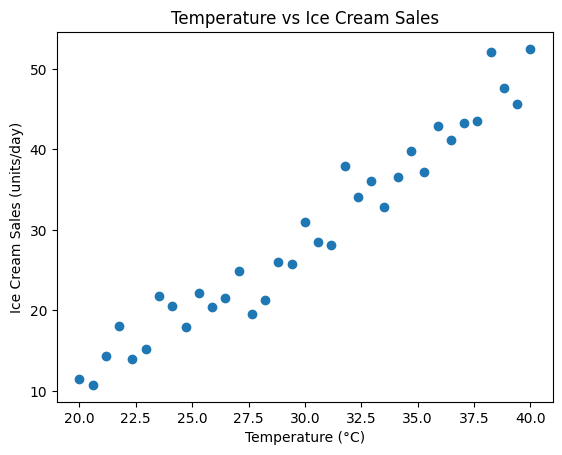

In [4]:
plt.scatter(data['Temperature'], data['IceCreamSales'])
plt.xlabel('Temperature (°C)')
plt.ylabel('Ice Cream Sales (units/day)')
plt.title('Temperature vs Ice Cream Sales')
plt.show()

## 3    Train / Test Split

In [5]:
from sklearn.model_selection import train_test_split

X = data['Temperature']
y = data['IceCreamSales']

X_train , X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42)


In [10]:
X.head()


0    20.000000
1    20.588235
2    21.176471
3    21.764706
4    22.352941
Name: Temperature, dtype: float64

In [11]:
y.head()

0    11.490142
1    10.761678
2    14.296007
3    18.098501
4    14.003422
Name: IceCreamSales, dtype: float64

## Fit Linear Regression Model

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# fitting the model
lin_reg = LinearRegression()
lin_reg.fit(X_train.to_frame(), y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [45]:
# Predicting.
y_pred = lin_reg.predict(X_test.to_frame())

rmse = np.sqrt(mean_squared_error(y_test , y_pred))
r2= r2_score(y_test, y_pred)
print(f"RMSE: {rmse:.2f}")
print(f"R^2: {r2:.2f}")

RMSE: 2.91
R^2: 0.86


## True vs Predicted Plot

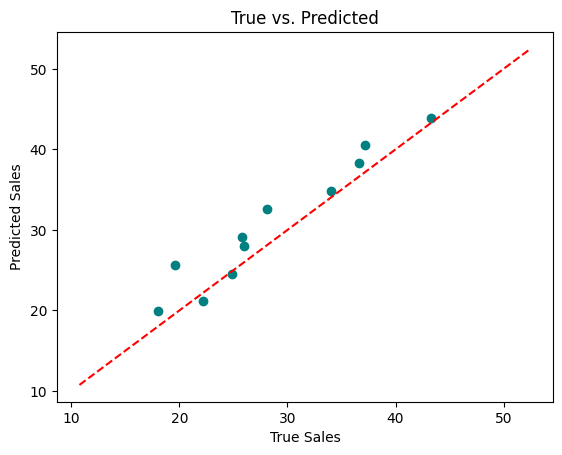

In [46]:
plt.scatter(y_test, y_pred, color='teal')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # 45° line
plt.xlabel('True Sales')
plt.ylabel('Predicted Sales')
plt.title('True vs. Predicted')
plt.show()

In [48]:
import statsmodels.api as sm

# Add constant for intercept
X_train_sm = sm.add_constant(X_train)
X_test_sm  = sm.add_constant(X_test)

ols = sm.OLS(y_train, X_train_sm).fit()
print(ols.summary())

# Predict with confidence intervals (95 %)
pred_summary = ols.get_prediction(X_test_sm).summary_frame(alpha=0.05)
pred_summary.head()

                            OLS Regression Results                            
Dep. Variable:          IceCreamSales   R-squared:                       0.957
Model:                            OLS   Adj. R-squared:                  0.955
Method:                 Least Squares   F-statistic:                     486.1
Date:                Sun, 10 Aug 2025   Prob (F-statistic):           1.72e-16
Time:                        16:06:15   Log-Likelihood:                -58.345
No. Observations:                  24   AIC:                             120.7
Df Residuals:                      22   BIC:                             123.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         -27.9262      2.693    -10.370      

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
26,40.530630,0.755750,38.963300,42.097960,34.368236,46.693023
13,25.698309,0.618542,24.415530,26.981087,19.602073,31.794544
24,38.248734,0.695152,36.807077,39.690391,32.117099,44.380369
21,34.825891,0.625716,33.528235,36.123547,28.726507,40.925275
15,27.980204,0.593879,26.748575,29.211834,21.894526,34.065883


## Visualize the Interval

KeyError: 'Temperature'

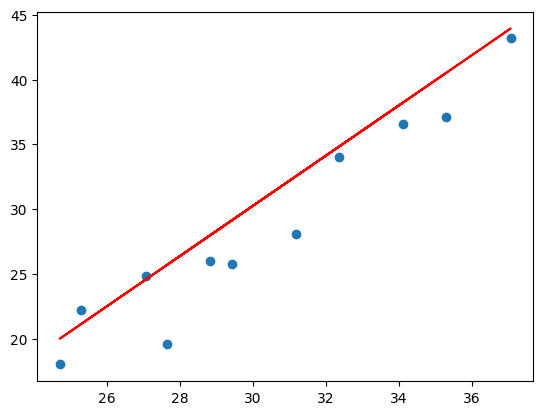

In [ ]:
plt.scatter(X_test, y_test, label='True')
plt.plot(X_test, pred_summary['mean'], color='red', label='Prediction')
plt.fill_between(
    X_test],
    pred_summary['mean_ci_lower'],
    pred_summary['mean_ci_upper'],
    color='red', alpha=0.2, label='95% CI')
plt.xlabel('Temperature')
plt.ylabel('Sales')
plt.legend()
plt.show()